In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
import shutil

DATASET_PATH = "/kaggle/input/datasets/bitsnpieces/ovarian-cancer-and-subtypes-dataset-histopathology/OvarianCancer"
OUTPUT_PATH = "/kaggle/working/train1"

classes = ["Mucinous", "Non_Cancerous", "Endometri", "Serous", "Clear_Cell"]

os.makedirs(OUTPUT_PATH, exist_ok=True)

for cls in classes:
    src_folder = os.path.join(DATASET_PATH, cls)
    dst_folder = os.path.join(OUTPUT_PATH, cls.replace(" ", "_"))
    os.makedirs(dst_folder, exist_ok=True)

    images = [f for f in os.listdir(src_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    for img in images:
        src_path = os.path.join(src_folder, img)
        dst_path = os.path.join(dst_folder, img)

        # Copy image
        shutil.copy2(src_path, dst_path)

    print(f"Class {cls}: {len(images)} images copied.")

print("All class images copied into train folder.")

Class Mucinous: 100 images copied.
Class Non_Cancerous: 100 images copied.
Class Endometri: 98 images copied.
Class Serous: 100 images copied.
Class Clear_Cell: 100 images copied.
All class images copied into train folder.


In [2]:
train_dir = "/kaggle/working/train1"

# **Data Visualization**

Classes: ['Serous', 'Non_Cancerous', 'Mucinous', 'Endometri', 'Clear_Cell']


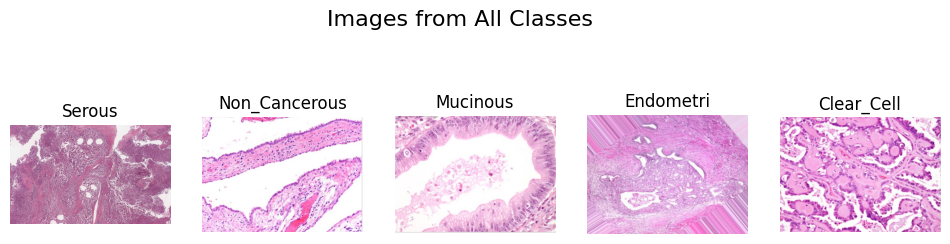

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

classes = os.listdir(train_dir)
print("Classes:", classes)

# Show one random image from each class
plt.figure(figsize=(12, 6))
for i, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)

    # Pick a random image from that class
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    # Read image
    img = mpimg.imread(img_path)

    # Plot
    plt.subplot(2, 5, i+1)  # 2 rows, 5 columns
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Images from All Classes", fontsize=16)
plt.show()

/tmp/ipykernel_58/1595876158.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="label", y="count", data=df, palette=he_colors)


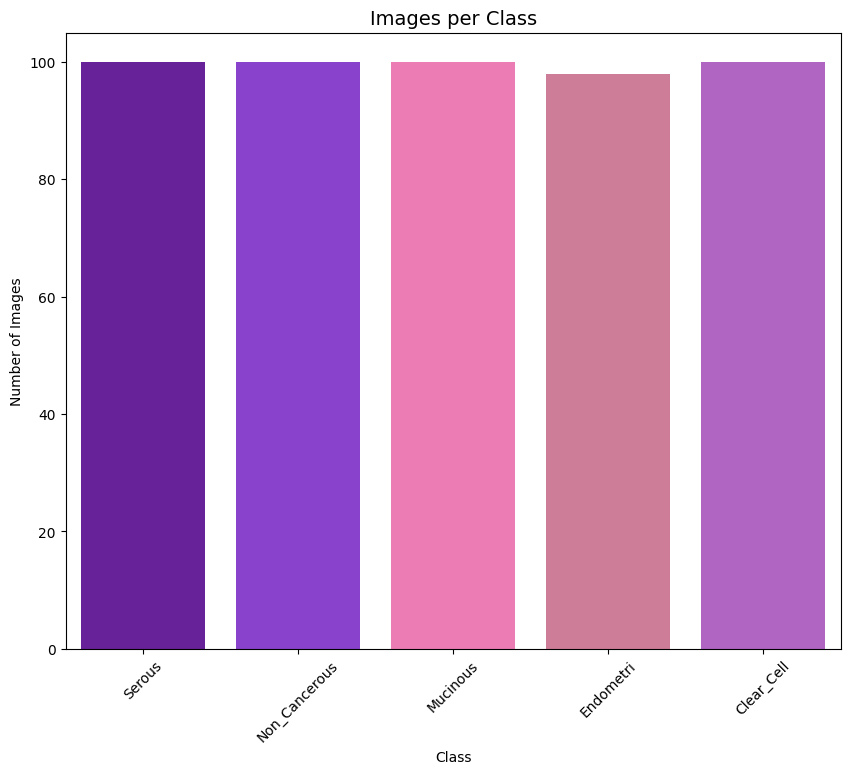

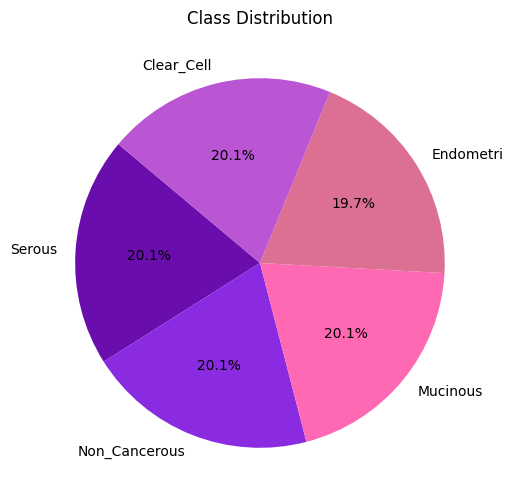

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Count images per class
df = pd.DataFrame([(cls, len(os.listdir(os.path.join(train_dir, cls))))
                   for cls in os.listdir(train_dir)], columns=["label", "count"])

# H&E-inspired colors (purple/blue + pink)
he_colors = ["#6A0DAD", "#8A2BE2", "#FF69B4", "#DB7093", "#BA55D3"]

# Bar chart
plt.figure(figsize=(10, 8))
sns.barplot(x="label", y="count", data=df, palette=he_colors)
plt.xticks(rotation=45)
plt.title("Images per Class", fontsize=14)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

# Pie chart
df.set_index("label")["count"].plot(kind="pie", autopct="%1.1f%%",
                                    startangle=140, figsize=(6,6),
                                    colors=he_colors)
plt.title("Class Distribution")
plt.ylabel("")
plt.show()

# **Split Train/Test Before Augmentation**

In [5]:
import os
import shutil
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
import numpy as np
import random

DATASET_PATH = "/kaggle/working/train1"
OUTPUT_TRAIN = "/kaggle/working/train_aug"
OUTPUT_TEST = "/kaggle/working/test"

classes = os.listdir(DATASET_PATH)
os.makedirs(OUTPUT_TRAIN, exist_ok=True)
os.makedirs(OUTPUT_TEST, exist_ok=True)

# Copy 100 images per class to test folder, rest to train folder
for cls in classes:
    cls_src = os.path.join(DATASET_PATH, cls)
    images = [f for f in os.listdir(cls_src) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(images)

    test_images = images[:20]
    train_images = images[20:]

    # Create class folders
    os.makedirs(os.path.join(OUTPUT_TEST, cls), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_TRAIN, cls), exist_ok=True)

    # Copy images
    for img in test_images:
        shutil.copy2(os.path.join(cls_src, img), os.path.join(OUTPUT_TEST, cls, img))
    for img in train_images:
        shutil.copy2(os.path.join(cls_src, img), os.path.join(OUTPUT_TRAIN, cls, img))

    print(f"{cls}: {len(train_images)} train images, {len(test_images)} test images")

Serous: 80 train images, 20 test images
Non_Cancerous: 80 train images, 20 test images
Mucinous: 80 train images, 20 test images
Endometri: 78 train images, 20 test images
Clear_Cell: 80 train images, 20 test images


# **Oversampling**

In [7]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

target_count = 500  # target per class

for cls in os.listdir(OUTPUT_TRAIN):
    cls_path = os.path.join(OUTPUT_TRAIN, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    current_count = len(images)

    if current_count >= target_count:
        print(f"Skipping {cls}: {current_count} images already present.")
        continue

    needed = target_count - current_count
    print(f"Augmenting {cls}: generating {needed} images...")

    img_index = 0
    for _ in range(needed):
        img_path = os.path.join(cls_path, images[img_index % len(images)])
        img = np.expand_dims(np.array(Image.open(img_path).convert("RGB")), axis=0)
        aug_iter = datagen.flow(img, batch_size=1, save_to_dir=cls_path, save_prefix="aug", save_format="jpg")
        next(aug_iter)
        img_index += 1

    # ✅ Print final image count for this class
    final_count = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f"✅ {cls} final image count: {final_count}")

print("✅ Train set augmented to target images per class.")

Augmenting Serous: generating 15 images...
✅ Serous final image count: 499
Augmenting Non_Cancerous: generating 10 images...
✅ Non_Cancerous final image count: 499
Augmenting Mucinous: generating 7 images...
✅ Mucinous final image count: 500
Augmenting Endometri: generating 7 images...
✅ Endometri final image count: 500
Augmenting Clear_Cell: generating 6 images...
✅ Clear_Cell final image count: 500
✅ Train set augmented to target images per class.


# **Imports**

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNet
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve
from tqdm import tqdm
import os
import random

# **Hyperparameters**

In [9]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 5

PROJECTION_DIM = 128

TEMPERATURE = 0.2
QUEUE_SIZE = 4096
MOMENTUM = 0.999

CHECKPOINT_DIR = "./moco_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# **Data Augmentation & Loading**

In [10]:
def random_augment(image):
    image = tf.image.resize(image, [256, 256])
    image = tf.image.random_crop(image, size=[224,224,3])

    image = tf.image.random_flip_left_right(image)

    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.8, 1.2)

    image = tf.clip_by_value(image, 0, 1)
    return image

def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)

    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0

    return img

def ssl_generator(image_paths, batch_size):
    while True:

        batch_paths = random.sample(image_paths, batch_size)

        q_batch = np.array([
            random_augment(load_image(p)).numpy()
            for p in batch_paths
        ])

        k_batch = np.array([
            random_augment(load_image(p)).numpy()
            for p in batch_paths
        ])

        yield q_batch, k_batch

# **MoCo Model with MobileNetV2**

In [11]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import tensorflow as tf

def create_encoder(projection_dim=128):

    base_model = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=(224,224,3)
    )

    # freeze earlier layers
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    for layer in base_model.layers[-30:]:
        layer.trainable = True

    inputs = layers.Input(shape=(224,224,3))

    x = base_model(inputs, training=True)

    x = layers.GlobalAveragePooling2D(name="gap")(x)

    # Projection head
    x = layers.Dense(512)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Dense(512)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    outputs = layers.Dense(projection_dim)(x)

    model = models.Model(inputs, outputs)

    return model

# ============================================================
# MOCO MODEL
# ============================================================

class MoCo(tf.keras.Model):

    def __init__(
        self,
        projection_dim=128,
        queue_size=4096,
        momentum=0.999,
        temperature=0.2
    ):

        super(MoCo, self).__init__()

        self.queue_size = queue_size
        self.momentum = momentum
        self.temperature = temperature

        # Query Encoder
        self.encoder_q = create_encoder(projection_dim)

        # Key Encoder
        self.encoder_k = create_encoder(projection_dim)

        # Initialize same weights
        self.encoder_k.set_weights(
            self.encoder_q.get_weights()
        )

        # Key encoder NOT trainable
        self.encoder_k.trainable = False

        # Queue
        self.queue = tf.Variable(
            tf.math.l2_normalize(
                tf.random.normal([projection_dim, queue_size]),
                axis=0
            ),
            trainable=False
        )

        self.queue_ptr = tf.Variable(0, dtype=tf.int32, trainable=False)

    # --------------------------------------------------------
    # Momentum Update
    # --------------------------------------------------------

    def momentum_update(self):

        for q_var, k_var in zip(
            self.encoder_q.variables,
            self.encoder_k.variables
        ):

            k_var.assign(
                self.momentum * k_var +
                (1.0 - self.momentum) * q_var
            )

    # --------------------------------------------------------
    # Queue Update
    # --------------------------------------------------------

    def dequeue_and_enqueue(self, keys):

        batch_size = tf.shape(keys)[0]

        ptr = self.queue_ptr

        keys = tf.transpose(keys)

        self.queue[:, ptr:ptr+batch_size].assign(keys)

        ptr = (ptr + batch_size) % self.queue_size

        self.queue_ptr.assign(ptr)

    # --------------------------------------------------------
    # Forward Pass
    # --------------------------------------------------------

    def call(self, im_q, im_k, training=True):

        # Query features
        q = self.encoder_q(im_q, training=True)
        q = tf.math.l2_normalize(q, axis=1)

        # Key features
        self.momentum_update()

        k = self.encoder_k(im_k, training=False)
        k = tf.math.l2_normalize(k, axis=1)

        # Positive logits
        l_pos = tf.reduce_sum(q * k, axis=1, keepdims=True)

        # Negative logits
        l_neg = tf.matmul(q, self.queue)

        # Combine
        logits = tf.concat([l_pos, l_neg], axis=1)

        logits /= self.temperature

        # Labels
        labels = tf.zeros(tf.shape(logits)[0], dtype=tf.int32)

        # Loss
        loss = tf.keras.losses.sparse_categorical_crossentropy(
            labels,
            logits,
            from_logits=True
        )

        loss = tf.reduce_mean(loss)

        # Update queue
        self.dequeue_and_enqueue(k)

        return loss

# **Prepare Dataset**

In [12]:
# ============================================================
# DATASET PREP
# ============================================================

train_dir = OUTPUT_TRAIN
test_dir = OUTPUT_TEST

def get_image_paths_labels(folder):

    image_paths = []
    labels = []

    classes = os.listdir(folder)

    for cls in classes:

        cls_dir = os.path.join(folder, cls)

        for f in os.listdir(cls_dir):

            if f.lower().endswith(('.jpg', '.jpeg', '.png')):

                image_paths.append(
                    os.path.join(cls_dir, f)
                )

                labels.append(cls)

    return image_paths, labels

train_paths, train_labels = get_image_paths_labels(train_dir)
test_paths, test_labels = get_image_paths_labels(test_dir)

print(f"Train: {len(train_paths)}")
print(f"Test: {len(test_paths)}")

steps_per_epoch = max(1, len(train_paths)//BATCH_SIZE)

Train: 2498
Test: 100


# **SSL Training Loop**

In [13]:
moco_model = MoCo(
    projection_dim=PROJECTION_DIM,
    queue_size=QUEUE_SIZE,
    momentum=MOMENTUM,
    temperature=TEMPERATURE
)

optimizer = tf.keras.optimizers.Adam(3e-4)

best_loss = np.inf

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    gen = ssl_generator(train_paths, BATCH_SIZE)

    epoch_loss = 0

    loop = tqdm(
        range(steps_per_epoch),
        desc="MoCo Training",
        ncols=100
    )

    for step in loop:

        x_q, x_k = next(gen)

        with tf.GradientTape() as tape:

            loss = moco_model(x_q, x_k, training=True)

        grads = tape.gradient(
            loss,
            moco_model.encoder_q.trainable_variables
        )

        optimizer.apply_gradients(
            zip(
                grads,
                moco_model.encoder_q.trainable_variables
            )
        )

        epoch_loss += loss.numpy()

        loop.set_postfix(loss=f"{loss.numpy():.4f}")

    epoch_loss /= steps_per_epoch

    print(f"Epoch {epoch+1}: loss={epoch_loss:.4f}")

    # Save Best
    if epoch_loss < best_loss:

        best_loss = epoch_loss

        moco_model.encoder_q.save(
            os.path.join(
                CHECKPOINT_DIR,
                "best_moco_encoder.keras"
            )
        )

        print("Model improved — saved ✔")

I0000 00:00:1783358171.192965      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783358171.196123      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Epoch 1/5


MoCo Training: 100%|███████████████████████████████████| 78/78 [02:11<00:00,  1.68s/it, loss=6.4367]


Epoch 1: loss=6.2191
Model improved — saved ✔

Epoch 2/5


MoCo Training: 100%|███████████████████████████████████| 78/78 [02:06<00:00,  1.62s/it, loss=6.4765]


...

Epoch 3: loss=6.2555

Epoch 4/5


MoCo Training: 100%|███████████████████████████████████| 78/78 [02:08<00:00,  1.65s/it, loss=5.8494]


Epoch 4: loss=5.9698
Model improved — saved ✔

Epoch 5/5


MoCo Training: 100%|███████████████████████████████████| 78/78 [02:08<00:00,  1.65s/it, loss=5.5914]


Epoch 5: loss=5.7300
Model improved — saved ✔


# **Linear Evaluation (Batched)**

In [14]:
# ============================================================
# LINEAR EVALUATION
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Load encoder
encoder = tf.keras.Model(
    inputs=moco_model.encoder_q.input,
    outputs=moco_model.encoder_q.get_layer("gap").output
)

# ------------------------------------------------------------
# Embedding Extraction
# ------------------------------------------------------------

def extract_embeddings_batch(model, image_paths, batch_size=32):

    imgs = np.array([
        load_image(p).numpy()
        for p in image_paths
    ])

    embeddings = model.predict(
        imgs,
        batch_size=batch_size,
        verbose=1
    )

    return embeddings

X_train = extract_embeddings_batch(
    encoder,
    train_paths,
    BATCH_SIZE
)

X_test = extract_embeddings_batch(
    encoder,
    test_paths,
    BATCH_SIZE
)

# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

clf = LogisticRegression(
    max_iter=2000,
    solver='saga'
)

clf.fit(X_train, train_labels)

preds = clf.predict(X_test)

acc = accuracy_score(test_labels, preds)

print(f"\nTest Accuracy: {acc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        test_labels,
        preds
    )
)

2026-07-06 17:27:25.126470: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 17:27:25.263850: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1783358846.805210     139 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


77/79 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

2026-07-06 17:27:38.558589: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 17:27:38.695338: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 171ms/step
3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

2026-07-06 17:27:49.452456: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 17:27:49.599087: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 17:27:49.735532: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step

Test Accuracy: 0.8900

Classification Report:
               precision    recall  f1-score   support

   Clear_Cell       0.83      0.95      0.88        20
    Endometri       0.95      1.00      0.98        20
     Mucinous       0.94      0.85      0.89        20
Non_Cancerous       0.94      0.80      0.86        20
       Serous       0.81      0.85      0.83        20

     accuracy                           0.89       100
    macro avg       0.89      0.89      0.89       100
 weighted avg       0.89      0.89      0.89       100



# **Evaluation**

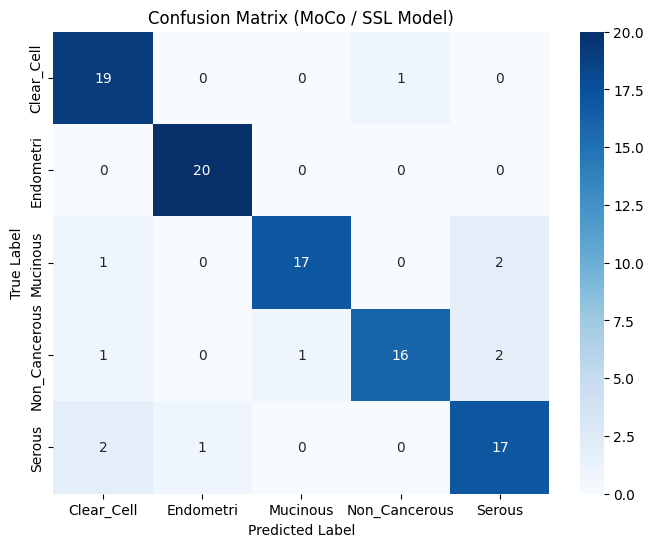

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(train_labels + test_labels)

preds = clf.predict(X_test)

cm = confusion_matrix(test_labels, preds)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (MoCo / SSL Model)")
plt.show()

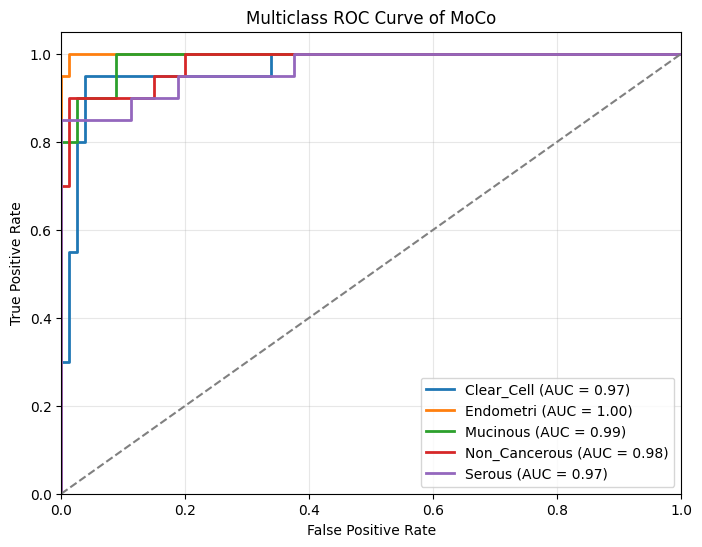

In [16]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. Ensure you are using probability outputs
# ============================================================
# IMPORTANT: must be predict_proba, not predict
probs = clf.predict_proba(X_test)

# ============================================================
# 2. Label binarization (safe version)
# ============================================================
classes = le.classes_
n_classes = len(classes)

y_test_bin = label_binarize(test_labels, classes=classes)

# ============================================================
# 3. Plot ROC
# ============================================================
plt.figure(figsize=(8, 6))

for i in range(n_classes):

    # Skip class if no samples in test set
    if np.sum(y_test_bin[:, i]) == 0:
        print(f"Warning: '{classes[i]}' not in test set")
        continue

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{classes[i]} (AUC = {roc_auc:.2f})"
    )

# ============================================================
# 4. Random baseline
# ============================================================
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

# ============================================================
# 5. Styling
# ============================================================
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve of MoCo")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

# **TTA + Uncertainty**

In [17]:
import numpy as np
import tensorflow as tf
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from scipy import stats

# ============================================================
# 1. CLEAN EMBEDDING EXTRACTION (NO TTA)
# ============================================================

def extract_embeddings_batch(model, image_paths, batch_size=32):

    all_embeddings = []

    for i in tqdm(range(0, len(image_paths), batch_size),
                  desc="Extracting embeddings"):

        batch = image_paths[i:i+batch_size]

        imgs = np.array([
            load_image(p).numpy()
            for p in batch
        ])

        embs = model.predict(imgs, verbose=0)

        all_embeddings.append(embs)

    return np.concatenate(all_embeddings, axis=0)

# ============================================================
# 2. FIXED TTA (deterministic per run)
# ============================================================

def tta_augment(image):

    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.15)
    image = tf.image.random_contrast(image, 0.8, 1.2)

    return tf.clip_by_value(image, 0, 1)

# ============================================================
# 3. PROPER TTA EMBEDDINGS
# ============================================================

def extract_embeddings_tta(model, image_paths, tta_runs=5, batch_size=32):

    all_embeddings = []

    for i in tqdm(range(0, len(image_paths), batch_size),
                  desc="TTA embeddings"):

        batch_paths = image_paths[i:i+batch_size]

        run_embeddings = []

        for _ in range(tta_runs):

            imgs = []

            for p in batch_paths:

                img = load_image(p)
                img = tta_augment(img)

                imgs.append(img.numpy())

            imgs = np.stack(imgs, axis=0)

            emb = model.predict(imgs, verbose=0)

            run_embeddings.append(emb)

        # shape: (TTA, batch, dim)
        run_embeddings = np.stack(run_embeddings, axis=0)

        # mean over TTA runs
        mean_emb = np.mean(run_embeddings, axis=0)

        all_embeddings.append(mean_emb)

    return np.concatenate(all_embeddings, axis=0)

# ============================================================
# 4. EXTRACT FEATURES
# ============================================================

X_train = extract_embeddings_batch(encoder, train_paths)
X_test = extract_embeddings_tta(encoder, test_paths, tta_runs=5)

# ============================================================
# 5. NORMALIZE EMBEDDINGS (VERY IMPORTANT)
# ============================================================

X_train = X_train / np.linalg.norm(X_train, axis=1, keepdims=True)
X_test = X_test / np.linalg.norm(X_test, axis=1, keepdims=True)

# ============================================================
# 6. CLASSIFIER
# ============================================================

clf = LogisticRegression(
    max_iter=2000,
    solver='saga'
)

clf.fit(X_train, train_labels)

# ============================================================
# 7. PREDICTIONS
# ============================================================

preds = clf.predict(X_test)
probs = clf.predict_proba(X_test)

# ============================================================
# 8. METRICS
# ============================================================

acc = accuracy_score(test_labels, preds)
print(f"Test Accuracy: {acc:.4f}")

# ============================================================
# 9. UNCERTAINTY (ENTROPY)
# ============================================================

uncertainty = stats.entropy(probs, axis=1)

print("Average Uncertainty:", np.mean(uncertainty))

TTA embeddings: 100%|██████████| 4/4 [00:06<00:00,  1.69s/it]


Test Accuracy: 0.8100
Average Uncertainty: 0.9597229


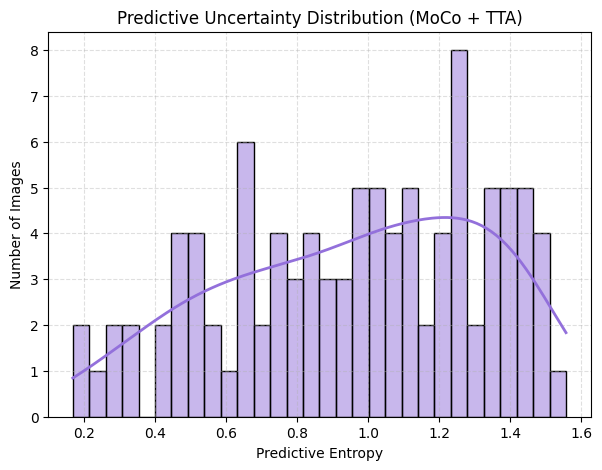

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. SAFE PROBABILITY CLIPPING
# ============================================================

probs_safe = np.clip(probs, 1e-8, 1.0)
probs_safe = probs_safe / np.sum(probs_safe, axis=1, keepdims=True)

# ============================================================
# 2. ENTROPY (PREDICTIVE UNCERTAINTY)
# ============================================================

entropy = -np.sum(probs_safe * np.log(probs_safe), axis=1)

# ============================================================
# 3. PLOT
# ============================================================

plt.figure(figsize=(7,5))

sns.histplot(
    entropy,
    bins=30,
    kde=True,
    color="mediumpurple",
    line_kws={"linewidth": 2}
)

plt.title("Predictive Uncertainty Distribution (MoCo + TTA)")
plt.xlabel("Predictive Entropy")
plt.ylabel("Number of Images")

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

# **Uncertainty vs Accuracy Analysis**

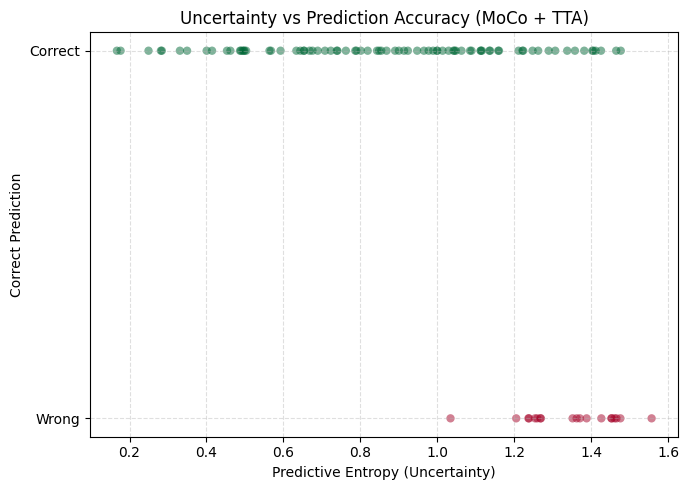

Average Entropy (Uncertainty): 0.959723
Accuracy: 0.81
Entropy (Correct Predictions): 0.8696678
Entropy (Wrong Predictions): 1.3436421


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. ENSURE CONSISTENT ARRAYS
# ============================================================

y_true = np.array(test_labels)   # ground truth
y_pred = np.array(preds)         # predicted labels from classifier

# ============================================================
# 2. COMPUTE CORRECTNESS MASK
# ============================================================

correct = (y_pred == y_true)

# ============================================================
# 3. SAFE ENTROPY COMPUTATION
# ============================================================

# probs already computed from: clf.predict_proba(X_test)

probs_safe = np.clip(probs, 1e-8, 1.0)
probs_safe = probs_safe / np.sum(probs_safe, axis=1, keepdims=True)

entropy = -np.sum(probs_safe * np.log(probs_safe), axis=1)

# ============================================================
# 4. SANITY CHECKS
# ============================================================

assert len(entropy) == len(y_true), "Mismatch in entropy and labels length"

# ============================================================
# 5. PLOT: UNCERTAINTY vs ACCURACY
# ============================================================

plt.figure(figsize=(7,5))

plt.scatter(
    entropy,
    correct.astype(int),
    c=correct,
    cmap="RdYlGn",
    alpha=0.5,
    edgecolor='none'
)

plt.title("Uncertainty vs Prediction Accuracy (MoCo + TTA)")
plt.xlabel("Predictive Entropy (Uncertainty)")
plt.ylabel("Correct Prediction")

plt.yticks([0, 1], ["Wrong", "Correct"])
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# ============================================================
# 6. OPTIONAL: SUMMARY STATISTICS
# ============================================================

print("Average Entropy (Uncertainty):", np.mean(entropy))
print("Accuracy:", np.mean(correct))
print("Entropy (Correct Predictions):", np.mean(entropy[correct]))
print("Entropy (Wrong Predictions):", np.mean(entropy[~correct]))

# **Prediction Confidence Distribution**

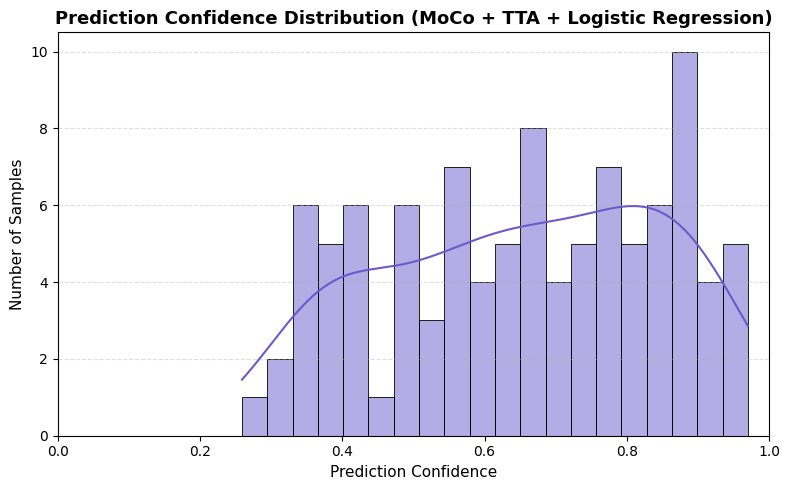

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. USE CORRECT VARIABLE
# ============================================================

probs = np.array(probs)

# numerical safety
probs = np.clip(probs, 1e-8, 1.0)

# confidence = max class probability
confidence = np.max(probs, axis=1)

# ============================================================
# 2. PLOT
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    confidence,
    bins=20,
    kde=True,
    color="#6a5acd",
    edgecolor="black",
    linewidth=0.6
)

# ============================================================
# 3. FORMATTING
# ============================================================

plt.title(
    "Prediction Confidence Distribution (MoCo + TTA + Logistic Regression)",
    fontsize=13,
    fontweight='bold'
)

plt.xlabel("Prediction Confidence", fontsize=11)
plt.ylabel("Number of Samples", fontsize=11)

plt.xlim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()